# Intro to the API

Start with LFADS on a small Lorenz dataset with 20 neurons, then reuse the same
experiment setup for NDT, LangevinFlow, and CASSM.

Open this notebook in Jupyter with LaDyS, NumPy, and Matplotlib installed in the
kernel's Python environment. Run the cells in order. Everything runs on CPU,
and no data download is needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ladys import Experiment, ExperimentConfig, PreprocessingConfig
from ladys.datasets import LorenzDatasetConfig
from ladys.models import LFADSConfig
from ladys.training import TrainerConfig

## Configure the experiment

Lorenz dynamics generate firing rates for 20 simulated neurons; Poisson sampling
turns those rates into spike counts. Training and validation use separate trials
of the same underlying trajectories.

`ExperimentConfig` combines the dataset, model, preprocessing, and training
settings. Here LFADS learns three factors from raw spike counts. The seed fixes
the generated data and the training randomness.

In [2]:
config = ExperimentConfig(
    dataset=LorenzDatasetConfig(
        neurons=20,
        num_inits=2,
        num_trials=8,
        num_steps=60,
        seed=0,
    ),
    model=LFADSConfig(factor_dim=3),
    preprocessing=PreprocessingConfig(),
    trainer=TrainerConfig(epochs=20, device="cpu"),
    batch_size=4,
    output_dir="runs/lorenz_tutorial",
    run_name="lfads",
)

## Train and evaluate

`Experiment.run()` prepares the data, builds and trains the model, evaluates it
on validation trials, and saves the run. The returned result contains the
learning history, evaluation metrics, and artifact paths.

In [3]:
result = Experiment(config).run()

epoch=1 train_loss=348.501 valid_loss=90.1082


epoch=2 train_loss=113.908 valid_loss=-156.989


epoch=3 train_loss=-42.4689 valid_loss=-275.053


epoch=4 train_loss=-78.6498 valid_loss=-257.046


epoch=5 train_loss=-155.606 valid_loss=-347.707


...

epoch=16 train_loss=-455.249 valid_loss=-538.819


epoch=17 train_loss=-498.717 valid_loss=-535.729


epoch=18 train_loss=-493.505 valid_loss=-559.198


epoch=19 train_loss=-515.361 valid_loss=-570.612


epoch=20 train_loss=-531.451 valid_loss=-559.87


## Plot learning curves

LFADS minimizes an ELBO-based objective that combines spike-count reconstruction
with latent regularization. Lower loss is better; validation evaluates trials
excluded from training.

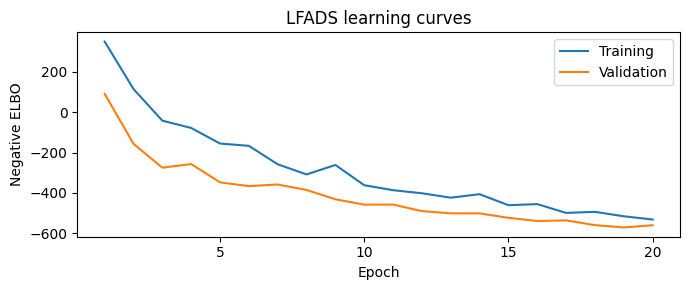

In [4]:
epochs = [report.epoch + 1 for report in result.history]
train_loss = [report.train.loss for report in result.history]
valid_loss = [report.valid.loss for report in result.history]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(epochs, train_loss, label="Training")
ax.plot(epochs, valid_loss, label="Validation")
ax.set(xlabel="Epoch", ylabel="Negative ELBO", title="LFADS learning curves")
ax.xaxis.get_major_locator().set_params(integer=True)
ax.legend()
fig.tight_layout()
plt.show()

## Inspect reconstructed activity

The saved predictions contain the model's estimated rates and the known Lorenz
rates for the validation trials. Compare them for one neuron in the first
validation trial. Ground-truth rates are used for evaluation, not training.

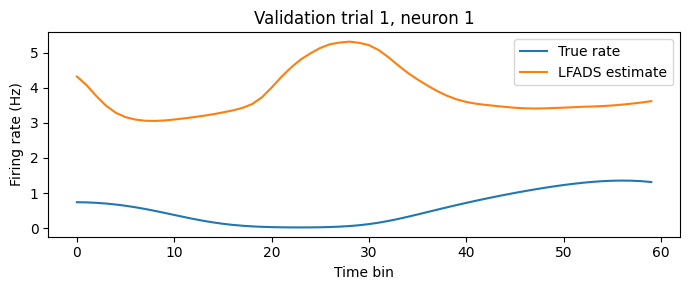

In [5]:
with np.load(result.predictions_path) as predictions:
    true_rates = predictions["target_rates"][0, :, 0]
    predicted_rates = predictions["pred_rates"][0, :, 0]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(true_rates, label="True rate")
ax.plot(predicted_rates, label="LFADS estimate")
ax.set(xlabel="Time bin", ylabel="Firing rate (Hz)", title="Validation trial 1, neuron 1")
ax.legend()
fig.tight_layout()
plt.show()

## Inspect the results

The run folder includes `config.json`, `history.csv`, `metrics.json`,
`model.pt`, and `predictions.npz`. The metrics below include rate reconstruction
error and latent reconstruction quality.

In [6]:
print(f"Run saved to: {result.run_dir}")
result.metrics

Run saved to: runs/lorenz_tutorial/lfads-1


{'co_bps': 0.5259796380996704,
 'poisson_nll': -0.48048165440559387,
 'rate_mse': 8.511946678161621,
 'rate_r2': 0.6007591485977173,
 'latent_linear_r2': 0.6971194954501367}

## Run NDT, LangevinFlow, and CASSM

Changing methods uses the same `Experiment` API. We choose small configurations
for the three additional models and use `dataclasses.replace` to reuse the
dataset, split, preprocessing, and training budget from the LFADS experiment.

These short runs illustrate the API; they are not tuned benchmark recipes.

In [7]:
from dataclasses import replace

from ladys.models import CASSMConfig, LangevinFlowConfig, NDTConfig

models = {
    "NDT": NDTConfig(hidden_size=64, num_layers=2),
    "LangevinFlow": LangevinFlowConfig(hidden_size=32, transformer_feedforward=128),
    "CASSM": CASSMConfig(projection_dim=5),
}
comparison_configs = {
    name: replace(
        config,
        model=model,
        output_dir=str(result.run_dir / "comparison"),
        run_name=model.name,
    )
    for name, model in models.items()
}

In [8]:
comparison_results = {
    name: Experiment(model_config).run()
    for name, model_config in comparison_configs.items()
}

epoch=1 train_loss=1.08636 valid_loss=1.03857


epoch=2 train_loss=0.963267 valid_loss=0.953457


epoch=3 train_loss=0.910399 valid_loss=0.867322


epoch=4 train_loss=0.787189 valid_loss=0.778181


epoch=5 train_loss=0.694004 valid_loss=0.685956


...

epoch=16 train_loss=3.88824 valid_loss=4.07282


epoch=17 train_loss=3.78608 valid_loss=3.97728


epoch=18 train_loss=3.70078 valid_loss=3.89271


epoch=19 train_loss=3.62754 valid_loss=3.81971


epoch=20 train_loss=3.56855 valid_loss=3.74882


## Inspect the three runs

Each model has its own loss definition and scale, so we plot the learning curves
separately. Regularization warmup can also change the scale of an objective
during training. All rate traces below use the same validation trial and neuron
as the LFADS plot.

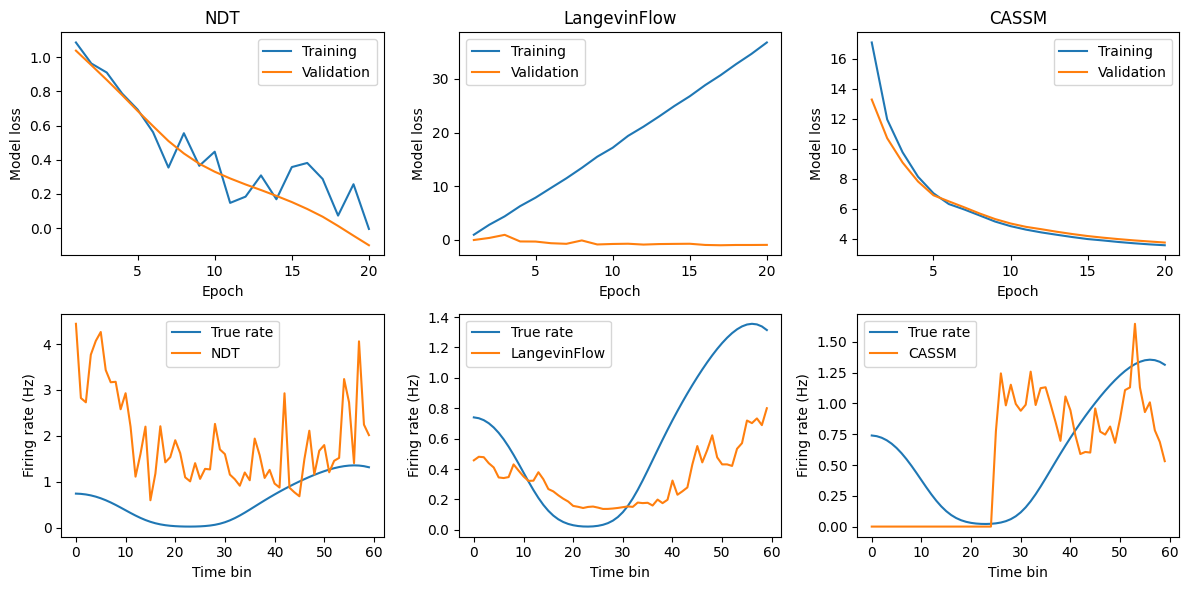

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for column, (name, model_result) in enumerate(comparison_results.items()):
    history = model_result.history
    epochs = [report.epoch + 1 for report in history]
    ax = axes[0, column]
    ax.plot(epochs, [report.train.loss for report in history], label="Training")
    ax.plot(epochs, [report.valid.loss for report in history], label="Validation")
    ax.set(title=name, xlabel="Epoch", ylabel="Model loss")
    ax.xaxis.get_major_locator().set_params(integer=True)
    ax.legend()

    with np.load(model_result.predictions_path) as predictions:
        ax = axes[1, column]
        ax.plot(predictions["target_rates"][0, :, 0], label="True rate")
        ax.plot(predictions["pred_rates"][0, :, 0], label=name)
    ax.set(xlabel="Time bin", ylabel="Firing rate (Hz)")
    ax.legend()

fig.tight_layout()
plt.show()

Rate mean squared error (MSE) provides a common metric across methods. These
values average over every validation trial, time bin, and neuron; lower is better.

In [10]:
all_results = {"LFADS": result, **comparison_results}
for name, model_result in all_results.items():
    print(f"{name:14s} rate MSE: {model_result.metrics['rate_mse']:.3f}")

LFADS          rate MSE: 8.512
NDT            rate MSE: 18.990
LangevinFlow   rate MSE: 13.206
CASSM          rate MSE: 5.910


## Reproduce the three runs with one command

The CLI accepts several YAML recipes or saved `config.json` files in one
invocation and runs them sequentially. The command below uses the exact
configurations saved by the three comparison runs, including the 20-neuron
dataset and each model's settings.

After executing the cells above, run the printed command from the notebook's
directory to train on a CUDA GPU. Use
`--device cpu` to run on CPU.

In [11]:
config_paths = " ".join(str(run.config_path) for run in comparison_results.values())
print(f"ladys run -c {config_paths} --device cuda")

ladys run -c runs/lorenz_tutorial/lfads-1/comparison/ndt/config.json runs/lorenz_tutorial/lfads-1/comparison/langevin_flow/config.json runs/lorenz_tutorial/lfads-1/comparison/cassm/config.json --device cuda


Try changing the LFADS factor count, a model's size, or the training budget and
rerun from the relevant configuration cell. For other models and configuration
options, see the [LaDyS documentation](https://zkunkworks.com/ladys/).